# 09 — Accuracy Comparison

Accuracy of all four trained models on the held-out retest set.

**Prerequisites:** run notebooks 02–05 to populate all model artifacts in `models/`.

## 1. Setup — Load Data & Models

In [16]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import joblib, sys
from pathlib import Path
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

sys.path.insert(0, '../src')
from features import STRUCTURAL_COLS, structural_features, build_features

MODELS_DIR   = Path("../models")
NGRAM_N      = 6
RANDOM_STATE = 42

# ── Training data ─────────────────────────────────────────────────────────────
lf = pd.read_csv("../data/train/train_login_form-2026-08.csv", sep=";")
nf = pd.read_csv("../data/train/train_no_form-2026-08.csv", index_col=0)
if "schreenshot_path" in nf.columns:
    nf.drop(columns=["schreenshot_path"], inplace=True)
lf.dropna(subset=["html_signature"], inplace=True)
nf.dropna(subset=["html_signature"], inplace=True)
df = pd.concat([lf, nf], ignore_index=True)
df = df.drop_duplicates(subset=["html_signature"]).reset_index(drop=True)
df["binary_label"] = (df["label"] == "LOGIN_FORM_MALICIOUS").astype(int)

df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["binary_label"], random_state=RANDOM_STATE
)

# ── Retest data ───────────────────────────────────────────────────────────────
lf_rt = pd.read_csv("../data/retest/signed_retest_login_form.csv", index_col=0)
nf_rt = pd.read_csv("../data/retest/signed_retest_no_form.csv",    index_col=0)
for df_ in [lf_rt, nf_rt]:
    for junk in ("Unnamed: 0", "schreenshot_path"):
        if junk in df_.columns:
            df_.drop(columns=[junk], inplace=True)
df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=["html_signature"], inplace=True)
df_rt.reset_index(drop=True, inplace=True)
df_rt["binary_label"] = df_rt["label"].str.contains("LOGIN_FORM", case=False, na=False).astype(int)

# ── Feature matrices ──────────────────────────────────────────────────────────
df_train = structural_features(df_train)
df_test  = structural_features(df_test)
df_rt    = structural_features(df_rt)

X_train_struct = df_train[STRUCTURAL_COLS].values;  y_train = df_train["binary_label"].values
X_test_struct  = df_test[STRUCTURAL_COLS].values;   y_test  = df_test["binary_label"].values
X_rt_struct    = df_rt[STRUCTURAL_COLS].values;     y_rt    = df_rt["binary_label"].values

with open(MODELS_DIR / "sequence_qualifying_seqs.json") as fh:
    QUALIFYING_SEQS = json.load(fh)
X_train_seq = build_features(df_train["html_signature"], QUALIFYING_SEQS, NGRAM_N)
X_test_seq  = build_features(df_test["html_signature"],  QUALIFYING_SEQS, NGRAM_N)
X_rt_seq    = build_features(df_rt["html_signature"],    QUALIFYING_SEQS, NGRAM_N)

# ── Load models & compute accuracies ─────────────────────────────────────────
MODELS = {
    "Structural XGBoost": (joblib.load(MODELS_DIR / "structural_xgboost.pkl"),      X_train_struct, X_test_struct, X_rt_struct),
    "Structural RF":      (joblib.load(MODELS_DIR / "structural_random_forest.pkl"), X_train_struct, X_test_struct, X_rt_struct),
    "Sequence XGBoost":   (joblib.load(MODELS_DIR / "sequence_xgboost.pkl"),         X_train_seq,    X_test_seq,    X_rt_seq),
    "Sequence RF":        (joblib.load(MODELS_DIR / "sequence_random_forest.pkl"),   X_train_seq,    X_test_seq,    X_rt_seq),
}
COLORS = {
    "Structural XGBoost": "#8e5bd9",
    "Structural RF":      "#5cb85c",
    "Sequence XGBoost":   "#e07b39",
    "Sequence RF":        "#3b85d8",
}

accuracies = {}
for name, (model, Xtr, Xte, Xrt) in MODELS.items():
    accuracies[name] = {
        "Train": accuracy_score(y_train, model.predict(Xtr)) * 100,
        "Test":  accuracy_score(y_test,  model.predict(Xte)) * 100,
        "Retest": accuracy_score(y_rt,   model.predict(Xrt)) * 100,
    }

print(f"Train : {len(df_train)} rows | Malicious: {int(y_train.sum())} | No-Form: {int((y_train==0).sum())}")
print(f"Test  : {len(df_test)} rows  | Malicious: {int(y_test.sum())} | No-Form: {int((y_test==0).sum())}")
print(f"Retest: {len(df_rt)} rows    | Malicious: {int(y_rt.sum())} | No-Form: {int((y_rt==0).sum())}")
print("\nAll models loaded.")

Train : 1657 rows | Malicious: 702 | No-Form: 955
Test  : 415 rows  | Malicious: 176 | No-Form: 239
Retest: 208 rows    | Malicious: 109 | No-Form: 99

All models loaded.


## 2. Accuracy Comparison

In [17]:
rows = []
for name, splits in accuracies.items():
    rows.append({
        "Model":     name,
        "Features":  "Structural" if "Structural" in name else "Sequence (6-gram)",
        "Algorithm": "XGBoost"     if "XGBoost"   in name else "Random Forest",
        "Train":     f"{splits['Train']:.1f}%",
        "Test":      f"{splits['Test']:.1f}%",
        "Retest":    f"{splits['Retest']:.1f}%",
    })
df_acc = pd.DataFrame(rows).set_index("Model")
display(df_acc)

,Features,Algorithm,Train,Test,Retest
Model,,,,,
Structural XGBoost,Structural,XGBoost,98.6%,92.0%,84.1%
Structural RF,Structural,Random Forest,97.2%,92.0%,81.7%
Sequence XGBoost,Sequence (6-gram),XGBoost,68.3%,69.4%,70.2%
Sequence RF,Sequence (6-gram),Random Forest,68.0%,69.2%,70.7%


In [ ]:
import mlflow

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("login-form-detection")
if exp:
    runs = client.search_runs(
        [exp.experiment_id],
        filter_string="status = 'FINISHED'",
        order_by=["start_time DESC"],
    )
    mlflow_rows = []
    for r in runs:
        m = r.data.metrics
        mlflow_rows.append({
            "Run":           r.data.tags.get("mlflow.runName", r.info.run_id[:8]),
            "Feature Track": r.data.params.get("feature_track", "?"),
            "Train Acc":     f"{m.get('train_accuracy', float('nan'))*100:.1f}%",
            "Test Acc":      f"{m.get('test_accuracy', float('nan'))*100:.1f}%",
            "Retest Acc":    f"{m.get('retest_accuracy', float('nan'))*100:.1f}%",
            "Retest AUC":    f"{m.get('retest_roc_auc', float('nan'))*100:.1f}%",
            "MAL Recall":    f"{m.get('retest_mal_recall', float('nan'))*100:.1f}%",
            "MAL Precision": f"{m.get('retest_mal_precision', float('nan'))*100:.1f}%",
        })
    if mlflow_rows:
        print("MLflow Experiment: login-form-detection")
        display(pd.DataFrame(mlflow_rows).set_index("Run"))
    else:
        print("No finished MLflow runs found. Run notebooks 02–05 first.")
else:
    print("MLflow experiment 'login-form-detection' not found. Run notebooks 02–05 first.")

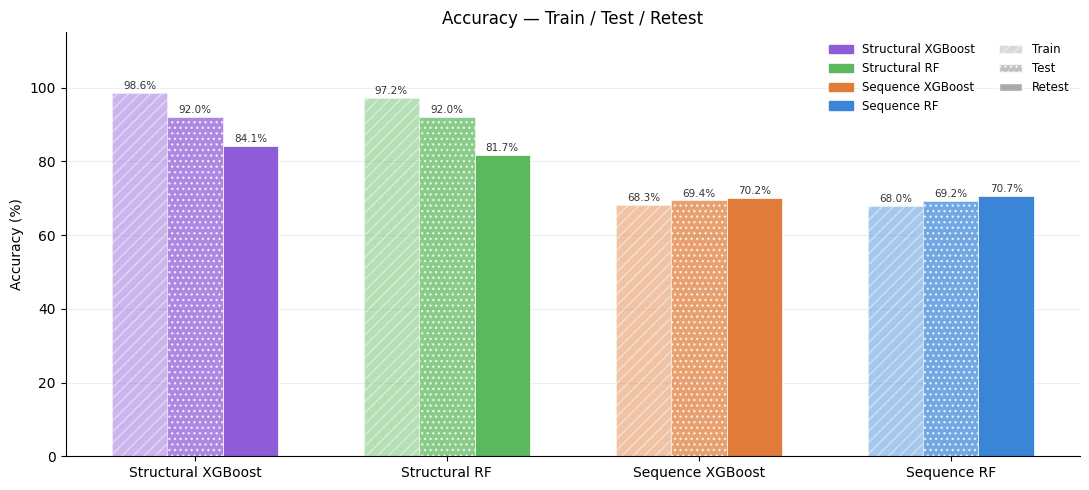

In [18]:
from matplotlib.patches import Patch

names  = list(accuracies.keys())
splits = ["Train", "Test", "Retest"]
n_models = len(names)
n_splits = len(splits)

x       = np.arange(n_models)
width   = 0.22
offsets = [-width, 0, width]

SPLIT_ALPHA = {"Train": 0.45, "Test": 0.72, "Retest": 1.0}
SPLIT_HATCH = {"Train": "///", "Test": "...", "Retest": ""}

fig, ax = plt.subplots(figsize=(11, 5))

for j, split in enumerate(splits):
    for i, name in enumerate(names):
        val   = accuracies[name][split]
        color = COLORS[name]
        bar   = ax.bar(
            x[i] + offsets[j], val, width,
            color=color,
            alpha=SPLIT_ALPHA[split],
            hatch=SPLIT_HATCH[split],
            edgecolor="white",
            linewidth=0.5,
        )
        ax.text(
            x[i] + offsets[j], val + 0.5,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=7.5, color="#333333",
        )

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy — Train / Test / Retest")
ax.grid(True, axis="y", color="#eeeeee", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

# Legend: model colors + split shading
model_handles = [Patch(color=COLORS[n], label=n) for n in names]
split_handles = [
    Patch(facecolor="#aaaaaa", alpha=SPLIT_ALPHA[s], hatch=SPLIT_HATCH[s],
          edgecolor="white", label=s)
    for s in splits
]
ax.legend(
    handles=model_handles + split_handles,
    frameon=False, fontsize=8.5,
    loc="upper right", ncol=2,
)

plt.tight_layout()
plt.show()